New Paper "Exact solutions for nonlinear partial
differential equations via a fusion
of classical methods and innovative
approaches"

Example 1

Differential Equation
$$
u_{tt} + x u_{xt} = x e^{-t} + 2u(u_t + x u_x) e^{-t}
$$

with the initial conditions:

$$
u(x, 0) = 1 \quad \text{and} \quad u_t(x, 0) = x + 1.
$$

The Exact solution is:

$$
u(x, t) = \sqrt{x} \, \tan \left( \sqrt{x} e^{-t} \left( -1 + e^t \left( \sqrt{x} - \arccos \left( \frac{-\sqrt{x}}{\sqrt{1 + x}} \right) \right) \right) \right)
$$

Epoch 0 : ODE Loss = 0.1366 IC Loss = 3.4612 Data Loss = 6.4801 Total Loss = 7.0994 Accuracy = -144.96%
Epoch 200 : ODE Loss = 0.0170 IC Loss = 3.2303 Data Loss = 0.8287 Total Loss = 1.1857 Accuracy = -1.25%
Epoch 400 : ODE Loss = 0.0247 IC Loss = 3.0575 Data Loss = 0.7628 Total Loss = 1.1180 Accuracy = 3.83%
Epoch 600 : ODE Loss = 0.0451 IC Loss = 2.7010 Data Loss = 0.4567 Total Loss = 0.8170 Accuracy = 30.14%
Epoch 800 : ODE Loss = 0.0115 IC Loss = 2.4088 Data Loss = 0.1338 Total Loss = 0.3976 Accuracy = 61.43%
Epoch 1000 : ODE Loss = 0.0368 IC Loss = 2.4130 Data Loss = 0.0871 Total Loss = 0.4021 Accuracy = 66.94%
Epoch 1200 : ODE Loss = 0.0044 IC Loss = 2.3786 Data Loss = 0.0515 Total Loss = 0.2981 Accuracy = 75.65%
Epoch 1400 : ODE Loss = 0.0108 IC Loss = 2.4160 Data Loss = 0.0618 Total Loss = 0.3249 Accuracy = 75.92%
Epoch 1600 : ODE Loss = 0.0036 IC Loss = 2.3685 Data Loss = 0.0282 Total Loss = 0.2722 Accuracy = 82.52%
Epoch 1800 : ODE Loss = 0.0146 IC Loss = 2.3814 Data Loss = 0

/tmp/ipython-input-1183807489.py:20: RuntimeWarning: divide by zero encountered in divide
  term_4 = np.exp(t) * (term_1 - term_3) / term_1
/tmp/ipython-input-1183807489.py:23: RuntimeWarning: invalid value encountered in multiply
  term_5 = term_1 * np.exp(-t) * (-1 + term_4)


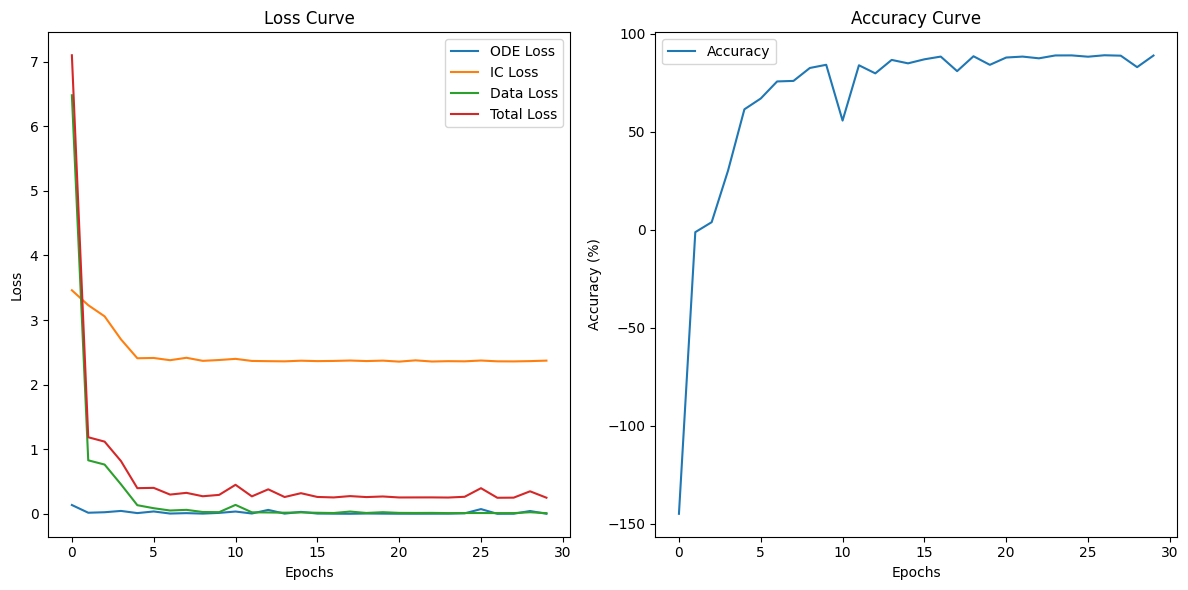

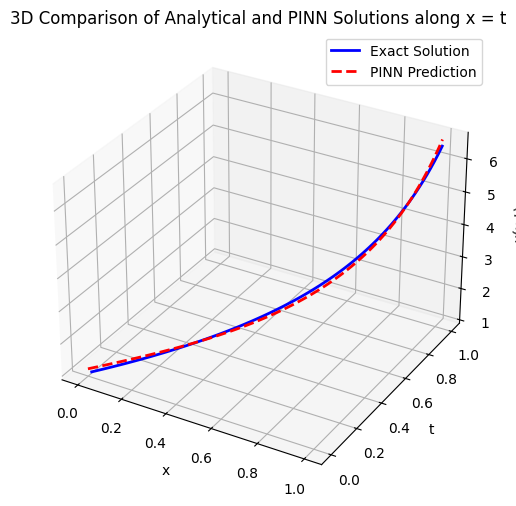

🔍 Custom PINN Model Summary


Model: "pinn_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (500, 50)              │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (500, 50)              │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (500, 50)              │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (500, 50)              │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (500, 50)              │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (500, 1)               │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,401 (40.63 KB)

 Trainable params: 10,401 (40.63 KB)

 Non-trainable params: 0 (0.00 B)


🧠 Additional Training Configuration:
➡ Activation Function: tanh
➡ Optimizer: Adam
➡ Learning Rate: 0.001
➡ Loss Function: MSE
➡ Final Training Loss: 0.261704
➡ Final Accuracy: 88.87%


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Exact solution (Modified based on the provided solution)
import numpy as np

# Exact solution (Modified based on the provided solution)
def exact_solution(x, t):
    # Term 1: Calculate sqrt(x)
    term_1 = np.sqrt(x)

    # Term 2: Calculate -sqrt(x) / sqrt(1 + x) for the arccos
    term_2 = -np.sqrt(x) / np.sqrt(1 + x)

    # Term 3: Calculate the arccos of term 2
    term_3 = np.arccos(term_2)

    # Term 4: Calculate e^t * (sqrt(x) - term_3) / sqrt(x)
    term_4 = np.exp(t) * (term_1 - term_3) / term_1

    # Term 5: Calculate sqrt(x) * e^(-t) * (-1 + term_4)
    term_5 = term_1 * np.exp(-t) * (-1 + term_4)

    # Final result: u(x,t) = sqrt(x) * tan(term_5)
    u = term_1 * np.tan(term_5)

    return u


# Define PINN Model as a class, similar to previous cells
class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(50, activation='tanh')
        self.dense2 = tf.keras.layers.Dense(50, activation='tanh')
        self.dense3 = tf.keras.layers.Dense(50, activation='tanh')
        self.dense4 = tf.keras.layers.Dense(50, activation='tanh')
        self.dense5 = tf.keras.layers.Dense(50, activation='tanh')
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs):
        h = self.dense1(inputs)
        h = self.dense2(h)
        h = self.dense3(h)
        h = self.dense4(h)
        h = self.dense5(h)
        return self.output_layer(h)

def physics_loss(model, x, t):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)
        tape2.watch(t)
        xt = tf.concat([x, t], axis=1)
        u = model(xt)

        # First derivative with respect to t
        u_t = tape2.gradient(u, t)

        # Second derivative with respect to t
        u_tt = tape2.gradient(u_t, t)

        # First derivative with respect to x
        u_x = tape2.gradient(u, x)

        # Mixed derivative with respect to x and t (first with x, then with t)
        u_xt = tape2.gradient(u_x, t)  # u_t is the first derivative of u with respect to t

    del tape2

    # Residual for the PDE: u_tt + x*u_xt - x*e^(-t) - 2*u*(u_t + x*u_x)*e^(-t)
    residual = u_tt + x * u_xt - x * tf.exp(-t) - 2 * u * (u_t + x * u_x) * tf.exp(-t)

    return tf.reduce_mean(tf.square(residual))

# Initial condition loss (Modified according to the problem)
def initial_condition_loss(model, x0):
    # This is the numerical value for t=0
    t0_val = tf.zeros_like(x0, dtype=tf.float32)
    # Make t0 a tf.Variable so that GradientTape can compute its gradient reliably
    t0_var = tf.Variable(t0_val)

    xt = tf.concat([x0, t0_var], axis=1) # Concatenate x0 (constant input) with t0_var (watched variable)

    with tf.GradientTape(persistent=True) as tape_ic:
        tape_ic.watch(t0_var) # Watch the variable t0_var

        # Predicted value from the model using the variable t0
        u_pred_ic = model(xt)

        # Calculate the predicted derivative with respect to t at t = 0
        u_t_pred = tape_ic.gradient(u_pred_ic, t0_var)

    del tape_ic

    # If u_t_pred is None, it indicates a problem in the gradient computation setup.
    # This should not happen after making t0 a tf.Variable and watching it.
    if u_t_pred is None:
        u_t_pred = tf.zeros_like(u_pred_ic) # Fallback to avoid crash, but indicates deeper issue

    # Exact solution for u(x,0) = 1
    u_true = tf.ones_like(x0)  # u(x,0) = 1

    # Exact solution for u_t(x,0) = x + 1
    u_t_true = x0 + 1  # u_t(x, 0) = x + 1

    # Loss for initial condition u(x,0) = 1
    u_loss = tf.reduce_mean(tf.square(u_pred_ic - u_true))

    # Loss for initial condition u_t(x,0) = x + 1
    u_t_loss = tf.reduce_mean(tf.square(u_t_pred - u_t_true))

    # Total loss
    total_loss = u_loss + u_t_loss
    return total_loss


# Supervised data loss (Unchanged)
def data_loss(model, x_d, t_d, u_d):
    xt_d = tf.concat([x_d, t_d], axis=1)
    u_pred = model(xt_d)
    return tf.reduce_mean(tf.square(u_pred - u_d))

# Total loss (Unchanged, just using the new functions)
def total_loss(model, x, t, x0, x_d, t_d, u_d, w_phys=2.0, w_ic=0.1, w_data=1.0):
    phys = physics_loss(model, x, t)
    ic = initial_condition_loss(model, x0)
    data = data_loss(model, x_d, t_d, u_d)
    return w_phys * phys + w_ic * ic + w_data * data

# Training setup (Changed to instantiate PINN class)
model = PINN()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Training data
N = 500
x = np.random.uniform(0, 1, (N, 1))
t = np.random.uniform(0, 1, (N, 1))
x0 = np.random.uniform(0, 1, (1000, 1))

# Supervised labeled data
N_data = 500
x_data = np.random.uniform(0, 1, (N_data, 1))
t_data = np.random.uniform(0, 1, (N_data, 1))
u_data = exact_solution(x_data, t_data)

# Convert data to tensors
x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
t_tf = tf.convert_to_tensor(t, dtype=tf.float32)
x0_tf = tf.convert_to_tensor(x0, dtype=tf.float32)
x_data_tf = tf.convert_to_tensor(x_data, dtype=tf.float32)
t_data_tf = tf.convert_to_tensor(t_data, dtype=tf.float32)
u_data_tf = tf.convert_to_tensor(u_data, dtype=tf.float32)

# Train the model
epochs = 6000 # Increased epochs for better training
losses = []
accuracies = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss_ode = physics_loss(model, x_tf, t_tf)
        loss_ic = initial_condition_loss(model, x0_tf)
        loss_data = data_loss(model, x_data_tf, t_data_tf, u_data_tf)
        total_loss_value = total_loss(model, x_tf, t_tf, x0_tf, x_data_tf, t_data_tf, u_data_tf)

    grads = tape.gradient(total_loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Tracking losses and accuracies
    if epoch % 200 == 0: # Print every 100 epochs
        # Compute RMSE for evaluation (not directly used in loss, but good for tracking progress)
        u_pred_train = model(tf.concat([x_tf, t_tf], axis=1))
        u_true_train = exact_solution(x, t)
        rmse = tf.sqrt(tf.reduce_mean(tf.square(u_pred_train - u_true_train)))
        # The accuracy metric (1 - RMSE) is a bit arbitrary, but we can keep it for now.
        # A better metric might be mean absolute error (MAE) or relative error.
        accuracy = 100 * (1 - rmse.numpy())

        losses.append([loss_ode.numpy(), loss_ic.numpy(), loss_data.numpy(), total_loss_value.numpy()])
        accuracies.append(accuracy)

        print(f"Epoch {epoch} : ODE Loss = {loss_ode.numpy():.4f} IC Loss = {loss_ic.numpy():.4f} Data Loss = {loss_data.numpy():.4f} Total Loss = {total_loss_value.numpy():.4f} Accuracy = {accuracy:.2f}%")

# Evaluation
x_test = np.linspace(0, 1, 100)
t_test = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_test, t_test)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
XT_test = tf.convert_to_tensor(np.hstack([X_flat, T_flat]), dtype=tf.float32)

u_pred = model(XT_test).numpy().reshape(100, 100)
u_exact = exact_solution(X, T)

# Plot loss and accuracy curves
losses = np.array(losses)
accuracies = np.array(accuracies)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(losses[:, 0], label="ODE Loss")
plt.plot(losses[:, 1], label="IC Loss")
plt.plot(losses[:, 2], label="Data Loss")
plt.plot(losses[:, 3], label="Total Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy Curve')
plt.tight_layout()
plt.show()

from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Assuming model and exact_solution are defined elsewhere as in the previous code

# Generate the mesh grid for x and t
x_test = np.linspace(0, 1, 100)
t_test = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_test, t_test)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
# Compute the PINN predictions
XT_test = tf.convert_to_tensor(np.hstack([X_flat, T_flat]), dtype=tf.float32)
u_pred = model(XT_test).numpy().reshape(100, 100)
# Compute the exact solution
u_exact = exact_solution(X, T)
# Plot the comparison in 3D line plots along the diagonal x = t
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# Plot the exact solution (blue line) along diagonal
ax.plot(x_test, t_test, np.diag(u_exact), color='blue', label="Exact Solution", linewidth=2)
# Plot the PINN solution (orange dashed line) along diagonal
ax.plot(x_test, t_test, np.diag(u_pred), color='red', linestyle='--', label="PINN Prediction", linewidth=2)
# Labels and title
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('3D Comparison of Analytical and PINN Solutions along x = t')
# Display the plot
plt.legend()
plt.show()

def print_custom_summary(model, learning_rate, activation_fn, optimizer_name, last_loss, last_accuracy, loss_fn_type):
    print("="*50)
    print("🔍 Custom PINN Model Summary")
    print("="*50)
    # Model summary with number of layers and neurons
    model.summary()  # Model architecture summary

    print("\n🧠 Additional Training Configuration:")
    # Printing relevant training settings and results
    print(f"➡ Activation Function: {activation_fn}")
    print(f"➡ Optimizer: {optimizer_name}")
    print(f"➡ Learning Rate: {learning_rate}")
    print(f"➡ Loss Function: {loss_fn_type}")
    print(f"➡ Final Training Loss: {last_loss:.6f}")
    print(f"➡ Final Accuracy: {last_accuracy:.2f}%")
    print("="*50)

# Usage of the custom summary function after training
print_custom_summary(
    model=model,
    learning_rate=0.001,
    activation_fn='tanh',  # Activation function used in the model
    optimizer_name='Adam',  # Optimizer used in training
    last_loss=total_loss_value.numpy(),  # Last computed total loss from training
    last_accuracy=accuracy,  # Last computed accuracy during training
    loss_fn_type='MSE'  # Loss function type used (e.g., Mean Squared Error)
)


Example 2

Differential Equation
$$
u_{tt} + u_{xt} = u_t^2 + u_x u_t
$$

with the initial conditions:

$$
u(x, 0) = 0 \quad \text{and} \quad u_t(x, 0) = x^2.
$$

The Exact solution is:

$$
u(x, t) = -\ln \left( 1 - \frac{t^3}{3} + t^2 x - t x^2 \right)
$$

Epoch 0 : ODE Loss = 0.0020 IC Loss = 0.0006 Data Loss = 0.0373 Total Loss = 0.0399 Accuracy = 72.57%
Epoch 200 : ODE Loss = 0.0001 IC Loss = 0.0006 Data Loss = 0.0040 Total Loss = 0.0047 Accuracy = 93.72%
Epoch 400 : ODE Loss = 0.0004 IC Loss = 0.0001 Data Loss = 0.0012 Total Loss = 0.0018 Accuracy = 96.54%
Epoch 600 : ODE Loss = 0.0003 IC Loss = 0.0000 Data Loss = 0.0004 Total Loss = 0.0007 Accuracy = 98.12%
Epoch 800 : ODE Loss = 0.0002 IC Loss = 0.0000 Data Loss = 0.0002 Total Loss = 0.0004 Accuracy = 98.50%
Epoch 1000 : ODE Loss = 0.0001 IC Loss = 0.0000 Data Loss = 0.0002 Total Loss = 0.0003 Accuracy = 98.63%
Epoch 1200 : ODE Loss = 0.0001 IC Loss = 0.0000 Data Loss = 0.0002 Total Loss = 0.0003 Accuracy = 98.70%
Epoch 1400 : ODE Loss = 0.0001 IC Loss = 0.0000 Data Loss = 0.0002 Total Loss = 0.0003 Accuracy = 98.76%
Epoch 1600 : ODE Loss = 0.0001 IC Loss = 0.0000 Data Loss = 0.0002 Total Loss = 0.0003 Accuracy = 98.57%
Epoch 1800 : ODE Loss = 0.0001 IC Loss = 0.0000 Data Loss = 0.

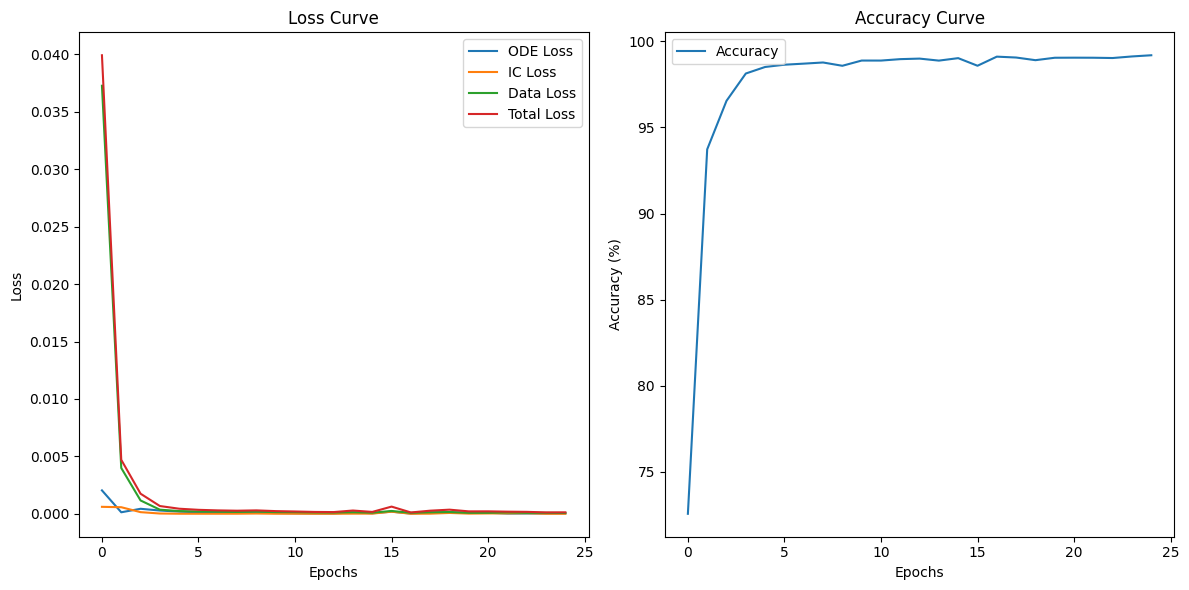

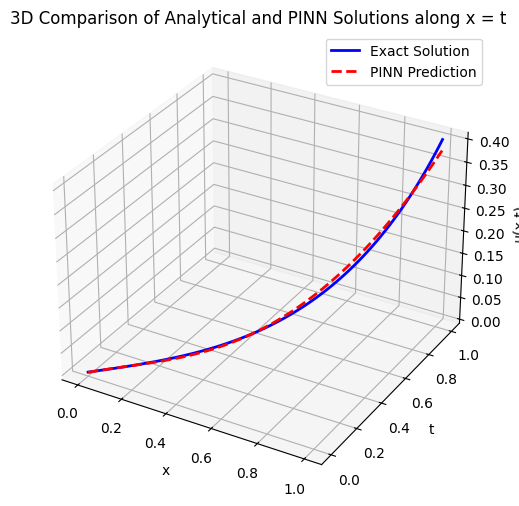

🔍 Custom PINN Model Summary


Model: "pinn_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (500, 100)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (500, 100)             │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (500, 100)             │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (500, 100)             │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (500, 100)             │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (500, 1)               │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,801 (159.38 KB)

 Trainable params: 40,801 (159.38 KB)

 Non-trainable params: 0 (0.00 B)


🧠 Additional Training Configuration:
➡ Activation Function: tanh
➡ Optimizer: Adam
➡ Learning Rate: 0.001
➡ Loss Function: MSE
➡ Final Training Loss: 0.000258
➡ Final Accuracy: 99.18%


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Exact solution (Modified based on the provided solution)
def exact_solution(x, t):
    # Ensure t**3 does not become negative in log argument
    return -np.log(1 - (t**3) / 3 + (t**2) * x - t * x**2)

# Define PINN Model as a class, similar to previous cells
class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(100, activation='tanh')
        self.dense2 = tf.keras.layers.Dense(100, activation='tanh')
        self.dense3 = tf.keras.layers.Dense(100, activation='tanh')
        self.dense4 = tf.keras.layers.Dense(100, activation='tanh')
        self.dense5 = tf.keras.layers.Dense(100, activation='tanh')
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs):
        h = self.dense1(inputs)
        h = self.dense2(h)
        h = self.dense3(h)
        h = self.dense4(h)
        h = self.dense5(h)
        return self.output_layer(h)

def physics_loss(model, x, t):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)
        tape2.watch(t)
        xt = tf.concat([x, t], axis=1)
        u = model(xt)
        # First derivative with respect to t
        u_t = tape2.gradient(u, t)
        # Second derivative with respect to t
        u_tt = tape2.gradient(u_t, t)
        # First derivative with respect to x
        u_x = tape2.gradient(u, x)
        # Mixed derivative with respect to x and t
        u_xt = tape2.gradient(u_t, x)
    del tape2

    # Residual for the PDE: u_tt + u_xt - u_t^2 - u_x * u_t
    residual = u_tt + u_xt - u_t**2 - u_x * u_t
    return tf.reduce_mean(tf.square(residual))


# Initial condition loss (Modified according to the problem)
def initial_condition_loss(model, x0):
    t0 = tf.zeros_like(x0)
    xt0 = tf.concat([x0, t0], axis=1)
    u_pred = model(xt0)
    u_true = tf.zeros_like(x0) # u(x,0) = 0 from exact solution
    return tf.reduce_mean(tf.square(u_pred - u_true))

# Supervised data loss (Unchanged)
def data_loss(model, x_d, t_d, u_d):
    xt_d = tf.concat([x_d, t_d], axis=1)
    u_pred = model(xt_d)
    return tf.reduce_mean(tf.square(u_pred - u_d))

# Total loss (Unchanged, just using the new functions)
def total_loss(model, x, t, x0, x_d, t_d, u_d, w_phys=1.0, w_ic=1.0, w_data=1.0):
    phys = physics_loss(model, x, t)
    ic = initial_condition_loss(model, x0)
    data = data_loss(model, x_d, t_d, u_d)
    return w_phys * phys + w_ic * ic + w_data * data

# Training setup (Changed to instantiate PINN class)
model = PINN()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Training data
N = 500
x = np.random.uniform(0, 1, (N, 1))
t = np.random.uniform(0, 1, (N, 1))
x0 = np.random.uniform(0, 1, (1000, 1))

# Supervised labeled data
N_data = 500
x_data = np.random.uniform(0, 1, (N_data, 1))
t_data = np.random.uniform(0, 1, (N_data, 1))
u_data = exact_solution(x_data, t_data)

# Convert data to tensors
x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
t_tf = tf.convert_to_tensor(t, dtype=tf.float32)
x0_tf = tf.convert_to_tensor(x0, dtype=tf.float32)
x_data_tf = tf.convert_to_tensor(x_data, dtype=tf.float32)
t_data_tf = tf.convert_to_tensor(t_data, dtype=tf.float32)
u_data_tf = tf.convert_to_tensor(u_data, dtype=tf.float32)

# Train the model
epochs = 5000 # Increased epochs for better training
losses = []
accuracies = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss_ode = physics_loss(model, x_tf, t_tf)
        loss_ic = initial_condition_loss(model, x0_tf)
        loss_data = data_loss(model, x_data_tf, t_data_tf, u_data_tf)
        total_loss_value = total_loss(model, x_tf, t_tf, x0_tf, x_data_tf, t_data_tf, u_data_tf)

    grads = tape.gradient(total_loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Tracking losses and accuracies
    if epoch % 200 == 0: # Print every 100 epochs
        # Compute RMSE for evaluation (not directly used in loss, but good for tracking progress)
        u_pred_train = model(tf.concat([x_tf, t_tf], axis=1))
        u_true_train = exact_solution(x, t)
        rmse = tf.sqrt(tf.reduce_mean(tf.square(u_pred_train - u_true_train)))
        # The accuracy metric (1 - RMSE) is a bit arbitrary, but we can keep it for now.
        # A better metric might be mean absolute error (MAE) or relative error.
        accuracy = 100 * (1 - rmse.numpy())

        losses.append([loss_ode.numpy(), loss_ic.numpy(), loss_data.numpy(), total_loss_value.numpy()])
        accuracies.append(accuracy)

        print(f"Epoch {epoch} : ODE Loss = {loss_ode.numpy():.4f} IC Loss = {loss_ic.numpy():.4f} Data Loss = {loss_data.numpy():.4f} Total Loss = {total_loss_value.numpy():.4f} Accuracy = {accuracy:.2f}%")

# Evaluation
x_test = np.linspace(0, 1, 100)
t_test = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_test, t_test)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
XT_test = tf.convert_to_tensor(np.hstack([X_flat, T_flat]), dtype=tf.float32)

u_pred = model(XT_test).numpy().reshape(100, 100)
u_exact = exact_solution(X, T)

# Plot loss and accuracy curves
losses = np.array(losses)
accuracies = np.array(accuracies)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(losses[:, 0], label="ODE Loss")
plt.plot(losses[:, 1], label="IC Loss")
plt.plot(losses[:, 2], label="Data Loss")
plt.plot(losses[:, 3], label="Total Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy Curve')
plt.tight_layout()
plt.show()

from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Assuming model and exact_solution are defined elsewhere as in the previous code

# Generate the mesh grid for x and t
x_test = np.linspace(0, 1, 100)
t_test = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_test, t_test)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
# Compute the PINN predictions
XT_test = tf.convert_to_tensor(np.hstack([X_flat, T_flat]), dtype=tf.float32)
u_pred = model(XT_test).numpy().reshape(100, 100)
# Compute the exact solution
u_exact = exact_solution(X, T)
# Plot the comparison in 3D line plots along the diagonal x = t
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# Plot the exact solution (blue line) along diagonal
ax.plot(x_test, t_test, np.diag(u_exact), color='blue', label="Exact Solution", linewidth=2)
# Plot the PINN solution (orange dashed line) along diagonal
ax.plot(x_test, t_test, np.diag(u_pred), color='red', linestyle='--', label="PINN Prediction", linewidth=2)
# Labels and title
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('3D Comparison of Analytical and PINN Solutions along x = t')
# Display the plot
plt.legend()
plt.show()

def print_custom_summary(model, learning_rate, activation_fn, optimizer_name, last_loss, last_accuracy, loss_fn_type):
    print("="*50)
    print("🔍 Custom PINN Model Summary")
    print("="*50)
    # Model summary with number of layers and neurons
    model.summary()  # Model architecture summary

    print("\n🧠 Additional Training Configuration:")
    # Printing relevant training settings and results
    print(f"➡ Activation Function: {activation_fn}")
    print(f"➡ Optimizer: {optimizer_name}")
    print(f"➡ Learning Rate: {learning_rate}")
    print(f"➡ Loss Function: {loss_fn_type}")
    print(f"➡ Final Training Loss: {last_loss:.6f}")
    print(f"➡ Final Accuracy: {last_accuracy:.2f}%")
    print("="*50)

# Usage of the custom summary function after training
print_custom_summary(
    model=model,
    learning_rate=0.001,
    activation_fn='tanh',  # Activation function used in the model
    optimizer_name='Adam',  # Optimizer used in training
    last_loss=total_loss_value.numpy(),  # Last computed total loss from training
    last_accuracy=accuracy,  # Last computed accuracy during training
    loss_fn_type='MSE'  # Loss function type used (e.g., Mean Squared Error)
)


Example 3

Differential Equation
$$
u_{tt} + u_{xt} + u_t = (u_t + u_x) u_t,
$$

with the initial conditions:

$$
u(x, 0) = 0 \quad \text{and} \quad u_t(x, 0) = x^2.
$$

The Exact solution is:

$$
u(x, t) = -\ln \left( e^{-t} t^2 + e^{-t} x^2 - 2 e^{-t} t x - 2 e^{-t} t + 2 e^{-t} x - x^2 + 2x - 1 \right)
$$

Epoch 0 : ODE Loss = 0.2107 IC Loss = 0.0553 Data Loss = 0.2374 Total Loss = 0.5033 Accuracy = 89.35%
Epoch 200 : ODE Loss = 0.0006 IC Loss = 0.0008 Data Loss = 0.0024 Total Loss = 0.0039 Accuracy = 94.77%
Epoch 400 : ODE Loss = 0.0002 IC Loss = 0.0006 Data Loss = 0.0021 Total Loss = 0.0029 Accuracy = 95.08%
Epoch 600 : ODE Loss = 0.0002 IC Loss = 0.0003 Data Loss = 0.0016 Total Loss = 0.0021 Accuracy = 95.77%
Epoch 800 : ODE Loss = 0.0001 IC Loss = 0.0001 Data Loss = 0.0005 Total Loss = 0.0007 Accuracy = 97.79%
Epoch 1000 : ODE Loss = 0.0001 IC Loss = 0.0000 Data Loss = 0.0002 Total Loss = 0.0003 Accuracy = 98.59%
Epoch 1200 : ODE Loss = 0.0001 IC Loss = 0.0000 Data Loss = 0.0001 Total Loss = 0.0002 Accuracy = 99.09%
Epoch 1400 : ODE Loss = 0.0000 IC Loss = 0.0000 Data Loss = 0.0001 Total Loss = 0.0001 Accuracy = 99.23%
Epoch 1600 : ODE Loss = 0.0001 IC Loss = 0.0001 Data Loss = 0.0002 Total Loss = 0.0003 Accuracy = 98.00%
Epoch 1800 : ODE Loss = 0.0000 IC Loss = 0.0000 Data Loss = 0.

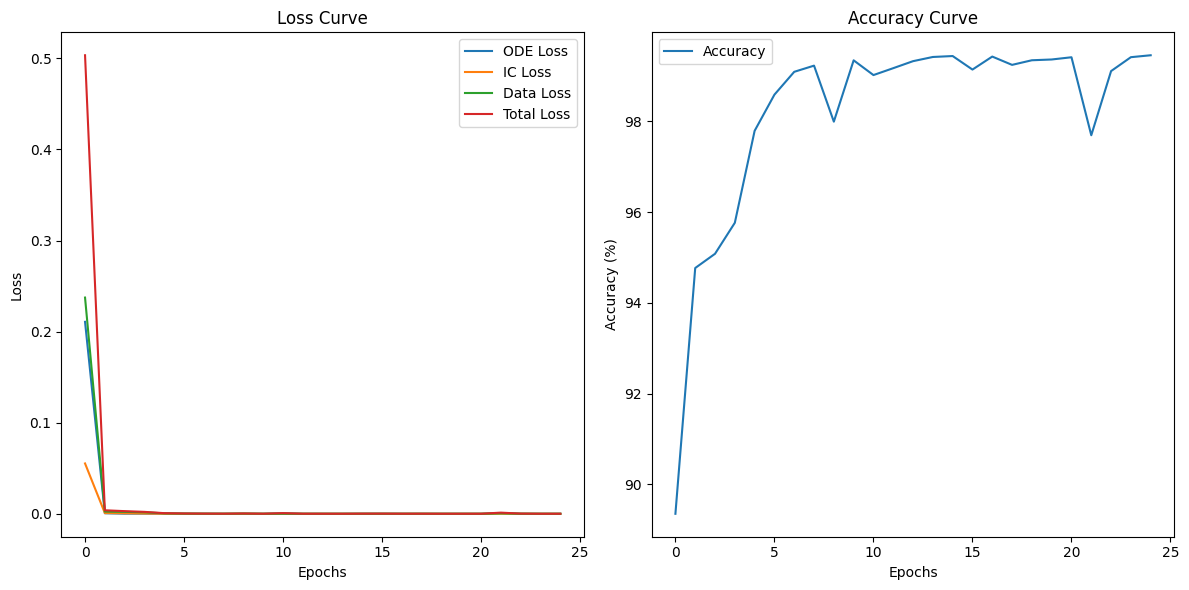

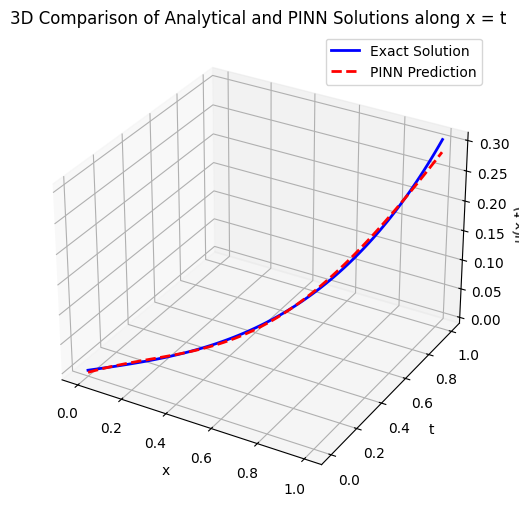

🔍 Custom PINN Model Summary


Model: "pinn_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (500, 100)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (500, 100)             │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (500, 100)             │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (500, 100)             │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (500, 100)             │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (500, 1)               │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,801 (159.38 KB)

 Trainable params: 40,801 (159.38 KB)

 Non-trainable params: 0 (0.00 B)


🧠 Additional Training Configuration:
➡ Activation Function: tanh
➡ Optimizer: Adam
➡ Learning Rate: 0.001
➡ Loss Function: MSE
➡ Final Training Loss: 0.000052
➡ Final Accuracy: 99.46%


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Exact solution (Modified based on the provided solution)
def exact_solution(x, t):
    return -np.log(np.exp(-t) * t**2 + np.exp(-t) * x**2 - 2 * np.exp(-t) * t * x - 2 * np.exp(-t) * x + 2 * np.exp(-t) * t + 2 * np.exp(-t) - x**2 + 2 * x - 1)


# Define PINN Model as a class, similar to previous cells
class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(100, activation='tanh')
        self.dense2 = tf.keras.layers.Dense(100, activation='tanh')
        self.dense3 = tf.keras.layers.Dense(100, activation='tanh')
        self.dense4 = tf.keras.layers.Dense(100, activation='tanh')
        self.dense5 = tf.keras.layers.Dense(100, activation='tanh')
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs):
        h = self.dense1(inputs)
        h = self.dense2(h)
        h = self.dense3(h)
        h = self.dense4(h)
        h = self.dense5(h)
        return self.output_layer(h)

def physics_loss(model, x, t):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)
        tape2.watch(t)
        xt = tf.concat([x, t], axis=1)
        u = model(xt)

        # First derivative with respect to t
        u_t = tape2.gradient(u, t)

        # Second derivative with respect to t
        u_tt = tape2.gradient(u_t, t)

        # First derivative with respect to x
        u_x = tape2.gradient(u, x)

        # Mixed derivative with respect to x and t
        u_xt = tape2.gradient(u_t, x)

    del tape2

    # Residual for the modified PDE: u_tt + u_xt + u_t - (u_t + u_x) * u_t
    residual = u_tt + u_xt + u_t - (u_t + u_x) * u_t

    return tf.reduce_mean(tf.square(residual))

# Initial condition loss (Modified according to the problem)
def initial_condition_loss(model, x0):
    t0 = tf.zeros_like(x0)
    xt0 = tf.concat([x0, t0], axis=1)
    u_pred = model(xt0)
    u_true = tf.zeros_like(x0) # u(x,0) = 0 from exact solution
    return tf.reduce_mean(tf.square(u_pred - u_true))

# Supervised data loss (Unchanged)
def data_loss(model, x_d, t_d, u_d):
    xt_d = tf.concat([x_d, t_d], axis=1)
    u_pred = model(xt_d)
    return tf.reduce_mean(tf.square(u_pred - u_d))

# Total loss (Unchanged, just using the new functions)
def total_loss(model, x, t, x0, x_d, t_d, u_d, w_phys=1.0, w_ic=1.0, w_data=1.0):
    phys = physics_loss(model, x, t)
    ic = initial_condition_loss(model, x0)
    data = data_loss(model, x_d, t_d, u_d)
    return w_phys * phys + w_ic * ic + w_data * data

# Training setup (Changed to instantiate PINN class)
model = PINN()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Training data
N = 500
x = np.random.uniform(0, 1, (N, 1))
t = np.random.uniform(0, 1, (N, 1))
x0 = np.random.uniform(0, 1, (1000, 1))

# Supervised labeled data
N_data = 500
x_data = np.random.uniform(0, 1, (N_data, 1))
t_data = np.random.uniform(0, 1, (N_data, 1))
u_data = exact_solution(x_data, t_data)

# Convert data to tensors
x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
t_tf = tf.convert_to_tensor(t, dtype=tf.float32)
x0_tf = tf.convert_to_tensor(x0, dtype=tf.float32)
x_data_tf = tf.convert_to_tensor(x_data, dtype=tf.float32)
t_data_tf = tf.convert_to_tensor(t_data, dtype=tf.float32)
u_data_tf = tf.convert_to_tensor(u_data, dtype=tf.float32)

# Train the model
epochs = 5000 # Increased epochs for better training
losses = []
accuracies = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss_ode = physics_loss(model, x_tf, t_tf)
        loss_ic = initial_condition_loss(model, x0_tf)
        loss_data = data_loss(model, x_data_tf, t_data_tf, u_data_tf)
        total_loss_value = total_loss(model, x_tf, t_tf, x0_tf, x_data_tf, t_data_tf, u_data_tf)

    grads = tape.gradient(total_loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Tracking losses and accuracies
    if epoch % 200 == 0: # Print every 100 epochs
        # Compute RMSE for evaluation (not directly used in loss, but good for tracking progress)
        u_pred_train = model(tf.concat([x_tf, t_tf], axis=1))
        u_true_train = exact_solution(x, t)
        rmse = tf.sqrt(tf.reduce_mean(tf.square(u_pred_train - u_true_train)))
        # The accuracy metric (1 - RMSE) is a bit arbitrary, but we can keep it for now.
        # A better metric might be mean absolute error (MAE) or relative error.
        accuracy = 100 * (1 - rmse.numpy())

        losses.append([loss_ode.numpy(), loss_ic.numpy(), loss_data.numpy(), total_loss_value.numpy()])
        accuracies.append(accuracy)

        print(f"Epoch {epoch} : ODE Loss = {loss_ode.numpy():.4f} IC Loss = {loss_ic.numpy():.4f} Data Loss = {loss_data.numpy():.4f} Total Loss = {total_loss_value.numpy():.4f} Accuracy = {accuracy:.2f}%")

# Evaluation
x_test = np.linspace(0, 1, 100)
t_test = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_test, t_test)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
XT_test = tf.convert_to_tensor(np.hstack([X_flat, T_flat]), dtype=tf.float32)

u_pred = model(XT_test).numpy().reshape(100, 100)
u_exact = exact_solution(X, T)

# Plot loss and accuracy curves
losses = np.array(losses)
accuracies = np.array(accuracies)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(losses[:, 0], label="ODE Loss")
plt.plot(losses[:, 1], label="IC Loss")
plt.plot(losses[:, 2], label="Data Loss")
plt.plot(losses[:, 3], label="Total Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy Curve')
plt.tight_layout()
plt.show()

from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Assuming model and exact_solution are defined elsewhere as in the previous code

# Generate the mesh grid for x and t
x_test = np.linspace(0, 1, 100)
t_test = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_test, t_test)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
# Compute the PINN predictions
XT_test = tf.convert_to_tensor(np.hstack([X_flat, T_flat]), dtype=tf.float32)
u_pred = model(XT_test).numpy().reshape(100, 100)
# Compute the exact solution
u_exact = exact_solution(X, T)
# Plot the comparison in 3D line plots along the diagonal x = t
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# Plot the exact solution (blue line) along diagonal
ax.plot(x_test, t_test, np.diag(u_exact), color='blue', label="Exact Solution", linewidth=2)
# Plot the PINN solution (orange dashed line) along diagonal
ax.plot(x_test, t_test, np.diag(u_pred), color='red', linestyle='--', label="PINN Prediction", linewidth=2)
# Labels and title
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('3D Comparison of Analytical and PINN Solutions along x = t')
# Display the plot
plt.legend()
plt.show()

def print_custom_summary(model, learning_rate, activation_fn, optimizer_name, last_loss, last_accuracy, loss_fn_type):
    print("="*50)
    print("🔍 Custom PINN Model Summary")
    print("="*50)
    # Model summary with number of layers and neurons
    model.summary()  # Model architecture summary

    print("\n🧠 Additional Training Configuration:")
    # Printing relevant training settings and results
    print(f"➡ Activation Function: {activation_fn}")
    print(f"➡ Optimizer: {optimizer_name}")
    print(f"➡ Learning Rate: {learning_rate}")
    print(f"➡ Loss Function: {loss_fn_type}")
    print(f"➡ Final Training Loss: {last_loss:.6f}")
    print(f"➡ Final Accuracy: {last_accuracy:.2f}%")
    print("="*50)

# Usage of the custom summary function after training
print_custom_summary(
    model=model,
    learning_rate=0.001,
    activation_fn='tanh',  # Activation function used in the model
    optimizer_name='Adam',  # Optimizer used in training
    last_loss=total_loss_value.numpy(),  # Last computed total loss from training
    last_accuracy=accuracy,  # Last computed accuracy during training
    loss_fn_type='MSE'  # Loss function type used (e.g., Mean Squared Error)
)


Paper 2 Approximate solution for quadratic Riccati differential equation

Example 5 from Paper 2

Differential Equation
$$
u'(t+2) - t^2 u(2t - 3) - u^2(t - 1) = 3 + 2t - 19t^2 + 20t^3 - 5t^4, \quad 0 \leq t \leq 1,
$$

with the initial condition:

$$
u(0) = -2,
$$

The Exact Solution is:

$$
u(t) = -2 - t + t^2
$$

Epoch 0 : ODE Loss = 3.7519 IC Loss = 4.0000 Data Loss = 4.6047 Total Loss = 12.3566 Accuracy = -75203.06%
Epoch 200 : ODE Loss = 0.1216 IC Loss = 0.0777 Data Loss = 0.0128 Total Loss = 0.2121 Accuracy = -140.81%
Epoch 400 : ODE Loss = 0.1159 IC Loss = 0.0775 Data Loss = 0.0150 Total Loss = 0.2084 Accuracy = -181.94%
Epoch 600 : ODE Loss = 0.1121 IC Loss = 0.0761 Data Loss = 0.0158 Total Loss = 0.2040 Accuracy = -197.59%
Epoch 800 : ODE Loss = 0.1082 IC Loss = 0.0721 Data Loss = 0.0152 Total Loss = 0.1955 Accuracy = -187.30%
Epoch 1000 : ODE Loss = 0.0960 IC Loss = 0.0619 Data Loss = 0.0119 Total Loss = 0.1698 Accuracy = -128.31%
Epoch 1200 : ODE Loss = 0.0636 IC Loss = 0.0324 Data Loss = 0.0038 Total Loss = 0.0998 Accuracy = 31.71%
Epoch 1400 : ODE Loss = 0.0403 IC Loss = 0.0150 Data Loss = 0.0074 Total Loss = 0.0627 Accuracy = -29.69%
Epoch 1600 : ODE Loss = 0.0291 IC Loss = 0.0091 Data Loss = 0.0061 Total Loss = 0.0443 Accuracy = -1.58%
Epoch 1800 : ODE Loss = 0.0153 IC Loss = 0.003

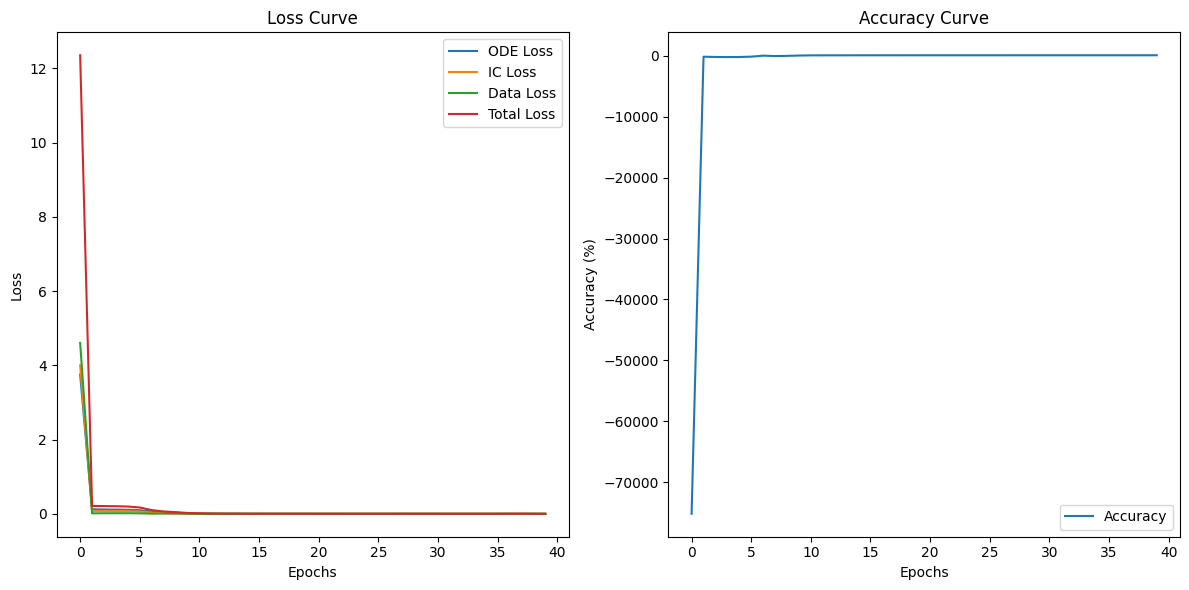

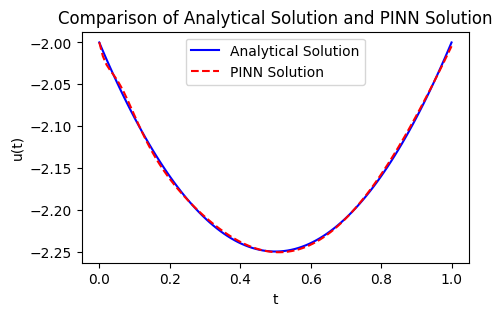

🔍 Custom PINN Model Summary
Model layers:
  - dense1: dense_30, output shape: (None, 50)
  - dense2: dense_31, output shape: (None, 50)
  - dense3: dense_32, output shape: (None, 50)
  - dense4: dense_33, output shape: (None, 50)
  - output_layer: dense_34, output shape: (None, 1)

🧠 Additional Training Configuration:
➡ Activation Function: tanh
➡ Optimizer: Adam
➡ Learning Rate: 0.000430467160185799
➡ Loss Function: MSE
➡ Final Training Loss: 0.000017
➡ Final Accuracy: 99.90%


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Some plot settings
plt.close('all')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

# Define the exact solution
def exact_solution(t):
    return -2 - t + t**2

# Define the neural network model
# create_model() - This function defines and returns a dictionary representing a neural network model.
# Within the dictionary the keys are the layer names and the values are the corresponding Dense layers.
def create_model():
    model = {
        'dense1': tf.keras.layers.Dense(50, activation='tanh'),
        'dense2': tf.keras.layers.Dense(50, activation='tanh'),
        'dense3': tf.keras.layers.Dense(50, activation='tanh'),
        'dense4': tf.keras.layers.Dense(50, activation='tanh'),
        'output_layer': tf.keras.layers.Dense(1)
    }
    return model

# call_model() - This function defines the forward pass of the neural network.
# It takes as input a dictionary model (created by create_model()) and an input tensor t.
def call_model(model, t):
    t = model['dense1'](t)
    t = model['dense2'](t)
    t = model['dense3'](t)
    t = model['dense4'](t)
    t = model['output_layer'](t)
    return t

# Define the differential equation using tf.GradientTape
def pde(t, model):
    t_plus2 = t + 2.0
    with tf.GradientTape() as tape:
        tape.watch(t_plus2)
        u_plus2 = call_model(model, t_plus2)
    u_prime_plus2 = tape.gradient(u_plus2, t_plus2)

    t_double_minus3 = 2.0 * t - 3.0
    u_double_minus3 = call_model(model, t_double_minus3)

    t_minus1 = t - 1.0
    u_minus1 = call_model(model, t_minus1)

    residual = u_prime_plus2 - t**2 * u_double_minus3 + u_minus1**2 - (3.0 + 2.0 * t - 19.0 * t**2 + 20.0 * t**3 - 5.0 * t**4)
    return residual

# Define the loss function
def loss(model, t, t_ic, u_ic, t_d, u_d):
    res = pde(t, model)
    # Compute the mean squared error of the ODE residual
    loss_ode = tf.reduce_mean(tf.square(res))
    u_ic_pred = call_model(model, t_ic)
    # Compute the mean squared error of the initial condition
    loss_ic = tf.reduce_mean(tf.square(u_ic - u_ic_pred))
    u_d_pred = call_model(model, t_d)
    # Compute the mean squared error of the data
    loss_data = tf.reduce_mean(tf.square(u_d - u_d_pred))
    total_loss = loss_ode + loss_ic + loss_data
    return total_loss, loss_ode, loss_ic, loss_data

# Define the training step
def train_step(model, t, t_ic, u_ic, t_d, u_d, optimizer):
    with tf.GradientTape() as tape:
        loss_value, loss_ode, loss_ic, loss_data = loss(model, t, t_ic, u_ic, t_d, u_d)
    grads = tape.gradient(loss_value, [layer.trainable_variables for layer in model.values()])
    # Flatten the list of trainable variables
    grads = [grad for sublist in grads for grad in sublist]
    variables = [var for layer in model.values() for var in layer.trainable_variables]
    optimizer.apply_gradients(zip(grads, variables))
    return loss_value, loss_ode, loss_ic, loss_data

# Setting up the problem
# Generate training data
t_train = np.linspace(0, 1, 100).reshape(-1, 1)
t_train = tf.convert_to_tensor(t_train, dtype=tf.float32)

# Initial condition data
t_ic = np.array([[0.0]], dtype=np.float32)
u_ic = np.array([[-2.0]], dtype=np.float32)
t_ic = tf.convert_to_tensor(t_ic, dtype=tf.float32)
u_ic = tf.convert_to_tensor(u_ic, dtype=tf.float32)

# Supervised labeled data
N_data = 100
t_data = np.random.uniform(0, 1, (N_data, 1))
u_data = exact_solution(t_data)
t_data = tf.convert_to_tensor(t_data, dtype=tf.float32)
u_data = tf.convert_to_tensor(u_data, dtype=tf.float32)

# Define the PINN model
model = create_model()

# Define the optimizer with a learning rate scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Lists to store losses and accuracy
losses_ode = []
losses_ic = []
losses_data = []
losses_total = []
accuracies = []

# Train the model
epochs = 8000 # Increased epochs for better training
for epoch in range(epochs):
    total_loss, loss_ode, loss_ic, loss_data = train_step(model, t_train, t_ic, u_ic, t_data, u_data, optimizer)

    # Compute accuracy using R^2 on collocation points
    if epoch % 200 == 0: # Print every 100 epochs
        u_pred_train = call_model(model, t_train)
        u_true_train = exact_solution(t_train.numpy())
        u_true_train_tf = tf.convert_to_tensor(u_true_train, dtype=tf.float32)
        mse = tf.reduce_mean(tf.square(u_pred_train - u_true_train_tf))
        var_true = tf.math.reduce_variance(u_true_train_tf)
        r2 = 1 - mse / var_true if var_true != 0 else 1.0
        accuracy = r2 * 100

        print(f"Epoch {epoch} : ODE Loss = {loss_ode.numpy():.4f} IC Loss = {loss_ic.numpy():.4f} Data Loss = {loss_data.numpy():.4f} Total Loss = {total_loss.numpy():.4f} Accuracy = {accuracy:.2f}%")

        # Append to lists
        losses_ode.append(loss_ode.numpy())
        losses_ic.append(loss_ic.numpy())
        losses_data.append(loss_data.numpy())
        losses_total.append(total_loss.numpy())
        accuracies.append(accuracy)

# Plot loss and accuracy curves
losses = np.column_stack([losses_ode, losses_ic, losses_data, losses_total])
accuracies = np.array(accuracies)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(losses[:, 0], label="ODE Loss")
plt.plot(losses[:, 1], label="IC Loss")
plt.plot(losses[:, 2], label="Data Loss")
plt.plot(losses[:, 3], label="Total Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy Curve')
plt.tight_layout()
plt.show()

# Predict the solution
t_test = np.linspace(0, 1, 100).reshape(-1, 1)
t_test_tf = tf.convert_to_tensor(t_test, dtype=tf.float32)
u_pred = call_model(model, t_test_tf).numpy()

# Analytical solution
u_true = exact_solution(t_test)

# Plot the results
plt.figure(figsize=(5, 3))
plt.plot(t_test, u_true, 'b-', label='Analytical Solution')
plt.plot(t_test, u_pred, 'r--', label='PINN Solution')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()
plt.title('Comparison of Analytical Solution and PINN Solution')
plt.show()

def print_custom_summary(model, learning_rate, activation_fn, optimizer_name, last_loss, last_accuracy, loss_fn_type):
    print("="*50)
    print("🔍 Custom PINN Model Summary")
    print("="*50)
    # Model summary with number of layers and neurons
    # The model here is a dictionary of layers, so we cannot directly call .summary()
    # Instead, we will print the layer names and their configurations if needed.
    print("Model layers:")
    for name, layer in model.items():
        print(f"  - {name}: {layer.name}, output shape: {layer.compute_output_shape(tf.TensorShape([None, 1]))}") # Assuming input shape is (None, 1)

    print("\n🧠 Additional Training Configuration:")
    # Printing relevant training settings and results
    print(f"➡ Activation Function: {activation_fn}")
    print(f"➡ Optimizer: {optimizer_name}")
    print(f"➡ Learning Rate: {learning_rate}")
    print(f"➡ Loss Function: {loss_fn_type}")
    print(f"➡ Final Training Loss: {last_loss:.6f}")
    print(f"➡ Final Accuracy: {last_accuracy:.2f}%")
    print("="*50)

# Usage of the custom summary function after training
# Ensure total_loss_value and accuracy are defined after the loop
# These values are only updated if the `if epoch % 2 == 0:` condition is met.
# For simplicity, we'll use the last recorded values from the lists.

# Check if lists are not empty before accessing last elements
if len(losses_total) > 0 and len(accuracies) > 0:
    last_loss_val = losses_total[-1]
    last_accuracy_val = accuracies[-1]
else:
    last_loss_val = 0.0 # Fallback values if no epochs were recorded
    last_accuracy_val = 0.0 # Fallback values if no epochs were recorded

print_custom_summary(
    model=model,
    learning_rate=lr_schedule(tf.cast(epochs, tf.float32)).numpy(), # Get final learning rate from scheduler
    activation_fn='tanh',  # Activation function used in the model
    optimizer_name='Adam',  # Optimizer used in training
    last_loss=last_loss_val,  # Last computed total loss from training
    last_accuracy=last_accuracy_val,  # Last computed accuracy during training
    loss_fn_type='MSE'  # Loss function type used (e.g., Mean Squared Error)
)

Example 2 second paper

Differential Equation
$$
u'(t) = 1 + 2u(t) - u^2(t), \quad 0 \leq t \leq 1,
$$

with the initial condition:

$$
u(0) = 0,
$$

The exact solution of the above equation is:

$$
u(t) = 1 + \sqrt{2} \, \tanh \left( \sqrt{2} t + \frac{1}{2} \ln \left( \frac{\sqrt{2} - 1}{\sqrt{2} + 1} \right) \right)
$$

Epoch 0 : ODE Loss = 0.9504 IC Loss = 0.0000 Data Loss = 1.2036 Total Loss = 2.1541 Accuracy = -325.85%
Epoch 200 : ODE Loss = 0.0709 IC Loss = 0.0013 Data Loss = 0.0156 Total Loss = 0.0878 Accuracy = 94.18%
Epoch 400 : ODE Loss = 0.0209 IC Loss = 0.0001 Data Loss = 0.0004 Total Loss = 0.0213 Accuracy = 99.71%
Epoch 600 : ODE Loss = 0.0005 IC Loss = 0.0000 Data Loss = 0.0000 Total Loss = 0.0005 Accuracy = 100.00%
Epoch 800 : ODE Loss = 0.0001 IC Loss = 0.0000 Data Loss = 0.0000 Total Loss = 0.0001 Accuracy = 100.00%
Epoch 1000 : ODE Loss = 0.0000 IC Loss = 0.0000 Data Loss = 0.0000 Total Loss = 0.0000 Accuracy = 100.00%
Epoch 1200 : ODE Loss = 0.0008 IC Loss = 0.0001 Data Loss = 0.0000 Total Loss = 0.0009 Accuracy = 99.98%
Epoch 1400 : ODE Loss = 0.0000 IC Loss = 0.0000 Data Loss = 0.0000 Total Loss = 0.0000 Accuracy = 100.00%
Epoch 1600 : ODE Loss = 0.0000 IC Loss = 0.0000 Data Loss = 0.0000 Total Loss = 0.0000 Accuracy = 100.00%
Epoch 1800 : ODE Loss = 0.0000 IC Loss = 0.0000 Data Lo

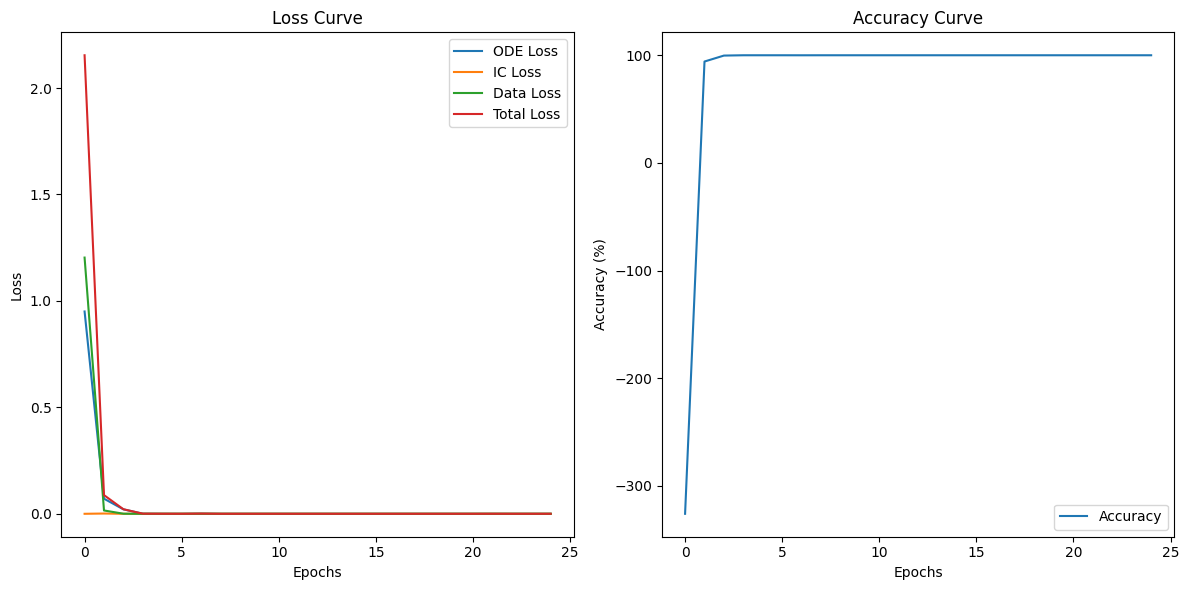

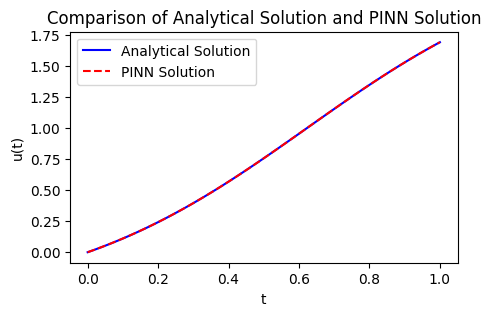

🔍 Custom PINN Model Summary
Model layers:
  - dense1: dense_45, output shape: (None, 50)
  - dense2: dense_46, output shape: (None, 50)
  - dense3: dense_47, output shape: (None, 50)
  - dense4: dense_48, output shape: (None, 50)
  - output_layer: dense_49, output shape: (None, 1)

🧠 Additional Training Configuration:
➡ Activation Function: tanh
➡ Optimizer: Adam
➡ Learning Rate: 0.0005904899444431067
➡ Loss Function: MSE
➡ Final Training Loss: 0.000001
➡ Final Accuracy: 100.00%


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Some plot settings
plt.close('all')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

# Define the exact solution
# Exact solution (Updated according to the problem)
def exact_solution(t):
    return 1 + np.sqrt(2) * np.tanh(np.sqrt(2) * t + (1 / 2) * np.log((np.sqrt(2) - 1) / (np.sqrt(2) + 1)))

# Define the neural network model
# create_model() - This function defines and returns a dictionary representing a neural network model.
# Within the dictionary the keys are the layer names and the values are the corresponding Dense layers.
def create_model():
    model = {
        'dense1': tf.keras.layers.Dense(50, activation='tanh'),
        'dense2': tf.keras.layers.Dense(50, activation='tanh'),
        'dense3': tf.keras.layers.Dense(50, activation='tanh'),
        'dense4': tf.keras.layers.Dense(50, activation='tanh'),
        'output_layer': tf.keras.layers.Dense(1)
    }
    return model

# call_model() - This function defines the forward pass of the neural network.
# It takes as input a dictionary model (created by create_model()) and an input tensor t.
def call_model(model, t):
    t = model['dense1'](t)
    t = model['dense2'](t)
    t = model['dense3'](t)
    t = model['dense4'](t)
    t = model['output_layer'](t)
    return t

# Define the differential equation u'(t) = 1 + 2u(t) - u^2(t)
def pde(t, model):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        u_pred = call_model(model, t)
        u_t = tape.gradient(u_pred, t)
    del tape
    # Residual for the PDE: u'(t) - (1 + 2u(t) - u^2(t))
    residual = u_t - (1 + 2 * u_pred - tf.square(u_pred))
    return residual

# Define the loss function
def loss(model, t, t_ic, u_ic, t_d, u_d):
    res = pde(t, model)
    # Compute the mean squared error of the ODE residual
    loss_ode = tf.reduce_mean(tf.square(res))
    u_ic_pred = call_model(model, t_ic)
    # Compute the mean squared error of the initial condition
    loss_ic = tf.reduce_mean(tf.square(u_ic - u_ic_pred))
    u_d_pred = call_model(model, t_d)
    # Compute the mean squared error of the data
    loss_data = tf.reduce_mean(tf.square(u_d - u_d_pred))
    total_loss = loss_ode + loss_ic + loss_data
    return total_loss, loss_ode, loss_ic, loss_data

# Define the training step
def train_step(model, t, t_ic, u_ic, t_d, u_d, optimizer):
    with tf.GradientTape() as tape:
        loss_value, loss_ode, loss_ic, loss_data = loss(model, t, t_ic, u_ic, t_d, u_d)
    grads = tape.gradient(loss_value, [layer.trainable_variables for layer in model.values()])
    # Flatten the list of trainable variables
    grads = [grad for sublist in grads for grad in sublist]
    variables = [var for layer in model.values() for var in layer.trainable_variables]
    optimizer.apply_gradients(zip(grads, variables))
    return loss_value, loss_ode, loss_ic, loss_data

# Setting up the problem
# Generate training data
t_train = np.linspace(0, 1, 100).reshape(-1, 1)
t_train = tf.convert_to_tensor(t_train, dtype=tf.float32)

# Initial condition data (t = 0, u(0) = 0)
t_ic = np.array([[0.0]], dtype=np.float32)  # Initial condition at t = 0
u_ic = np.array([[0.0]], dtype=np.float32)  # u(0) = 0
t_ic = tf.convert_to_tensor(t_ic, dtype=tf.float32)
u_ic = tf.convert_to_tensor(u_ic, dtype=tf.float32)

# Supervised labeled data
N_data = 100
t_data = np.random.uniform(0, 1, (N_data, 1))
u_data = exact_solution(t_data)
t_data = tf.convert_to_tensor(t_data, dtype=tf.float32)
u_data = tf.convert_to_tensor(u_data, dtype=tf.float32)

# Define the PINN model
model = create_model()

# Define the optimizer with a learning rate scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Lists to store losses and accuracy
losses_ode = []
losses_ic = []
losses_data = []
losses_total = []
accuracies = []

# Train the model
epochs = 5000 # Increased epochs for better training
for epoch in range(epochs):
    total_loss, loss_ode, loss_ic, loss_data = train_step(model, t_train, t_ic, u_ic, t_data, u_data, optimizer)

    # Compute accuracy using R^2 on collocation points
    if epoch % 200 == 0: # Print every 100 epochs
        u_pred_train = call_model(model, t_train)
        u_true_train = exact_solution(t_train.numpy())
        u_true_train_tf = tf.convert_to_tensor(u_true_train, dtype=tf.float32)
        mse = tf.reduce_mean(tf.square(u_pred_train - u_true_train_tf))
        var_true = tf.math.reduce_variance(u_true_train_tf)
        r2 = 1 - mse / var_true if var_true != 0 else 1.0
        accuracy = r2 * 100

        print(f"Epoch {epoch} : ODE Loss = {loss_ode.numpy():.4f} IC Loss = {loss_ic.numpy():.4f} Data Loss = {loss_data.numpy():.4f} Total Loss = {total_loss.numpy():.4f} Accuracy = {accuracy:.2f}%")

        # Append to lists
        losses_ode.append(loss_ode.numpy())
        losses_ic.append(loss_ic.numpy())
        losses_data.append(loss_data.numpy())
        losses_total.append(total_loss.numpy())
        accuracies.append(accuracy)

# Plot loss and accuracy curves
losses = np.column_stack([losses_ode, losses_ic, losses_data, losses_total])
accuracies = np.array(accuracies)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(losses[:, 0], label="ODE Loss")
plt.plot(losses[:, 1], label="IC Loss")
plt.plot(losses[:, 2], label="Data Loss")
plt.plot(losses[:, 3], label="Total Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy Curve')
plt.tight_layout()
plt.show()

# Predict the solution
t_test = np.linspace(0, 1, 100).reshape(-1, 1)
t_test_tf = tf.convert_to_tensor(t_test, dtype=tf.float32)
u_pred = call_model(model, t_test_tf).numpy()

# Analytical solution
u_true = exact_solution(t_test)

# Plot the results
plt.figure(figsize=(5, 3))
plt.plot(t_test, u_true, 'b-', label='Analytical Solution')
plt.plot(t_test, u_pred, 'r--', label='PINN Solution')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()
plt.title('Comparison of Analytical Solution and PINN Solution')
plt.show()

def print_custom_summary(model, learning_rate, activation_fn, optimizer_name, last_loss, last_accuracy, loss_fn_type):
    print("="*50)
    print("🔍 Custom PINN Model Summary")
    print("="*50)
    # Model summary with number of layers and neurons
    # The model here is a dictionary of layers, so we cannot directly call .summary()
    # Instead, we will print the layer names and their configurations if needed.
    print("Model layers:")
    for name, layer in model.items():
        print(f"  - {name}: {layer.name}, output shape: {layer.compute_output_shape(tf.TensorShape([None, 1]))}") # Assuming input shape is (None, 1)

    print("\n🧠 Additional Training Configuration:")
    # Printing relevant training settings and results
    print(f"➡ Activation Function: {activation_fn}")
    print(f"➡ Optimizer: {optimizer_name}")
    print(f"➡ Learning Rate: {learning_rate}")
    print(f"➡ Loss Function: {loss_fn_type}")
    print(f"➡ Final Training Loss: {last_loss:.6f}")
    print(f"➡ Final Accuracy: {last_accuracy:.2f}%")
    print("="*50)

# Usage of the custom summary function after training
# Ensure total_loss_value and accuracy are defined after the loop
# These values are only updated if the `if epoch % 2 == 0:` condition is met.
# For simplicity, we'll use the last recorded values from the lists.

# Check if lists are not empty before accessing last elements
if len(losses_total) > 0 and len(accuracies) > 0:
    last_loss_val = losses_total[-1]
    last_accuracy_val = accuracies[-1]
else:
    last_loss_val = 0.0 # Fallback values if no epochs were recorded
    last_accuracy_val = 0.0 # Fallback values if no epochs were recorded

print_custom_summary(
    model=model,
    learning_rate=lr_schedule(tf.cast(epochs, tf.float32)).numpy(), # Get final learning rate from scheduler
    activation_fn='tanh',  # Activation function used in the model
    optimizer_name='Adam',  # Optimizer used in training
    last_loss=last_loss_val,  # Last computed total loss from training
    last_accuracy=last_accuracy_val,  # Last computed accuracy during training
    loss_fn_type='MSE'  # Loss function type used (e.g., Mean Squared Error)
)

Example 1 second paper

Differential Equation
$$
u'(t) = 16t^2 - 5 + 8t u(t) + u^2(t), \quad 0 \leq t \leq 1,
$$

with the initial condition:

$$
u(0) = 1,
$$

The exact solution is:

$$
u(t) = 1 - 4t
$$

Epoch 0 : ODE Loss = 22.7576  IC Loss = 1.0000  Data Loss = 2.2539  Total Loss = 26.0115  Accuracy = -51.00%
Epoch 100 : ODE Loss = 0.0112  IC Loss = 0.0028  Data Loss = 0.0364  Total Loss = 0.0504  Accuracy = 97.25%
Epoch 200 : ODE Loss = 0.0125  IC Loss = 0.0015  Data Loss = 0.0286  Total Loss = 0.0426  Accuracy = 97.89%
Epoch 300 : ODE Loss = 0.0111  IC Loss = 0.0013  Data Loss = 0.0241  Total Loss = 0.0365  Accuracy = 98.22%
Epoch 400 : ODE Loss = 0.0100  IC Loss = 0.0011  Data Loss = 0.0205  Total Loss = 0.0316  Accuracy = 98.49%
Epoch 500 : ODE Loss = 0.0091  IC Loss = 0.0010  Data Loss = 0.0178  Total Loss = 0.0279  Accuracy = 98.69%
Epoch 600 : ODE Loss = 0.0084  IC Loss = 0.0009  Data Loss = 0.0156  Total Loss = 0.0249  Accuracy = 98.85%
Epoch 700 : ODE Loss = 0.0078  IC Loss = 0.0008  Data Loss = 0.0139  Total Loss = 0.0225  Accuracy = 98.97%
Epoch 800 : ODE Loss = 0.0073  IC Loss = 0.0007  Data Loss = 0.0126  Total Loss = 0.0206  Accuracy = 99.07%
Epoch 900 : ODE Loss = 0.00

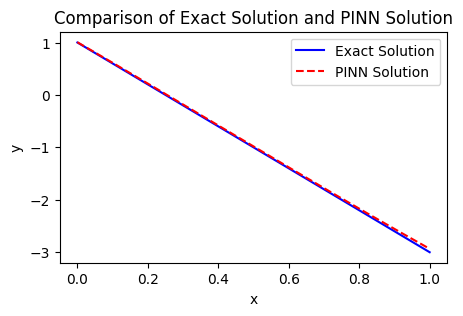

🔍 Custom PINN Model Summary
Model layers:
  - dense1: dense_104, output shape: (None, 50)
  - dense2: dense_105, output shape: (None, 50)
  - dense3: dense_106, output shape: (None, 50)
  - output_layer: dense_107, output shape: (None, 1)

🧠 Additional Training Configuration:
➡ Activation Function: tanh
➡ Optimizer: Adam
➡ Learning Rate: 0.0007289999630302191
➡ Loss Function: MSE
➡ Final Training Loss: 0.749798
➡ Final Accuracy: 93.02%


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Some plot settings
plt.close('all')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

# Define the neural network model
def create_model():
    model = {
        'dense1': tf.keras.layers.Dense(50, activation='tanh'),
        'dense2': tf.keras.layers.Dense(50, activation='tanh'),
        'dense3': tf.keras.layers.Dense(50, activation='tanh'),
        'output_layer': tf.keras.layers.Dense(1)
    }
    return model

# Forward pass of the neural network
def call_model(model, x):
    x = model['dense1'](x)
    x = model['dense2'](x)
    x = model['dense3'](x)
    x = model['output_layer'](x)
    return x

# Define the differential equation using tf.GradientTape
def pde(x, model):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        y_pred = call_model(model, x)
        y_x = tape.gradient(y_pred, x)
    del tape
    # Equation: dy/dx = 16x^2 - 5 + 8xy + y^2
    return y_x - (16 * x**2 - 5 + 8 * x * y_pred + tf.square(y_pred))

# Loss function with weights for data, initial condition, and ODE loss
def loss(model, x, x_ic, y_ic, x_data, y_data, lambda_data=1.0, lambda_ic=1.0, lambda_ode=1.0):
    # ODE loss term (Loss_ODE)
    res = pde(x, model)
    loss_ode = tf.reduce_mean(tf.square(res))

    # Initial Condition loss term (Loss_IC)
    y_ic_pred = call_model(model, x_ic)
    loss_ic = tf.reduce_mean(tf.square(y_ic - y_ic_pred))

    # Data loss term (Loss_data)
    y_data_pred = call_model(model, x_data)
    loss_data = tf.reduce_mean(tf.square(y_data - y_data_pred))

    # Total loss function with weights for each term
    total_loss = lambda_data * loss_data + lambda_ic * loss_ic + lambda_ode * loss_ode
    return loss_ode, loss_ic, loss_data, total_loss

# Training step
def train_step(model, x, x_ic, y_ic, optimizer, x_data, y_data, lambda_data=1.0, lambda_ic=1.0, lambda_ode=1.0):
    with tf.GradientTape() as tape:
        loss_ode, loss_ic, loss_data, total_loss = loss(model, x, x_ic, y_ic, x_data, y_data, lambda_data, lambda_ic, lambda_ode)
    grads = tape.gradient(total_loss, [layer.trainable_variables for layer in model.values()])
    grads = [grad for sublist in grads for grad in sublist]  # Flatten gradients list
    variables = [var for layer in model.values() for var in layer.trainable_variables]
    optimizer.apply_gradients(zip(grads, variables))
    return loss_ode, loss_ic, loss_data, total_loss

# Setting up the problem
# Generate training data (x_train)
x_train = np.linspace(0, 1, 100).reshape(-1, 1)
x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)

# Initial condition data (x_ic, y_ic)
x_ic = np.array([[0.0]], dtype=np.float32)  # Initial condition at x = 0
y_ic = np.array([[1.0]], dtype=np.float32)  # y(0) = 1
x_ic = tf.convert_to_tensor(x_ic, dtype=tf.float32)
y_ic = tf.convert_to_tensor(y_ic, dtype=tf.float32)

# Generate 1000 random data points for the input (x_data) between 0 and 1
x_data = np.random.uniform(0, 1, 1000)
x_data = np.reshape(x_data, (-1, 1))  # Reshape to (1000, 1) as required for the model
x_data = tf.convert_to_tensor(x_data, dtype=tf.float32)

# Generate random output data (y_data) for the corresponding x_data (we'll use the exact solution here for simplicity)
def exact_solution(x):
    return 1 - 4 * x

y_data = exact_solution(x_data.numpy())  # Use the exact solution for random data points
y_data = tf.convert_to_tensor(y_data, dtype=tf.float32)

# Define the PINN model
model = create_model()

# Define the optimizer with a learning rate scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Train the model
epochs = 3000
lambda_data = 1.0  # Weight for data loss
lambda_ic = 1.0    # Weight for initial condition loss
lambda_ode = 1.0   # Weight for ODE loss

for epoch in range(epochs):
    loss_ode, loss_ic, loss_data, total_loss = train_step(model, x_train, x_ic, y_ic, optimizer, x_data, y_data, lambda_data, lambda_ic, lambda_ode)

# Compute accuracy using R^2 on collocation points
    if epoch % 100 == 0: # Print every 100 epochs
        u_pred_train = call_model(model, t_train)
        u_true_train = exact_solution(t_train.numpy())
        u_true_train_tf = tf.convert_to_tensor(u_true_train, dtype=tf.float32)
        mse = tf.reduce_mean(tf.square(u_pred_train - u_true_train_tf))
        var_true = tf.math.reduce_variance(u_true_train_tf)
        r2 = 1 - mse / var_true if var_true != 0 else 1.0
        accuracy = r2 * 100

    if epoch % 100 == 0:
        print(f"Epoch {epoch} : ODE Loss = {loss_ode.numpy():.4f}  IC Loss = {loss_ic.numpy():.4f}  Data Loss = {loss_data.numpy():.4f}  Total Loss = {total_loss.numpy():.4f}  Accuracy = {accuracy:.2f}%")

# Predict the solution
x_test = np.linspace(0, 1, 1000).reshape(-1, 1)
x_test = tf.convert_to_tensor(x_test, dtype=tf.float32)
y_pred = call_model(model, x_test).numpy()

# Analytical solution
y_true = exact_solution(x_test.numpy())

# Plot the results
plt.figure(figsize=(5, 3))
plt.plot(x_test, y_true, 'b-', label='Exact Solution')
plt.plot(x_test, y_pred, 'r--', label='PINN Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Comparison of Exact Solution and PINN Solution')
plt.show()

def print_custom_summary(model, learning_rate, activation_fn, optimizer_name, last_loss, last_accuracy, loss_fn_type):
    print("="*50)
    print("🔍 Custom PINN Model Summary")
    print("="*50)
    # Model summary with number of layers and neurons
    # The model here is a dictionary of layers, so we cannot directly call .summary()
    # Instead, we will print the layer names and their configurations if needed.
    print("Model layers:")
    for name, layer in model.items():
        print(f"  - {name}: {layer.name}, output shape: {layer.compute_output_shape(tf.TensorShape([None, 1]))}") # Assuming input shape is (None, 1)

    print("\n🧠 Additional Training Configuration:")
    # Printing relevant training settings and results
    print(f"➡ Activation Function: {activation_fn}")
    print(f"➡ Optimizer: {optimizer_name}")
    print(f"➡ Learning Rate: {learning_rate}")
    print(f"➡ Loss Function: {loss_fn_type}")
    print(f"➡ Final Training Loss: {last_loss:.6f}")
    print(f"➡ Final Accuracy: {last_accuracy:.2f}%")
    print("="*50)

# Usage of the custom summary function after training
# Ensure total_loss_value and accuracy are defined after the loop
# These values are only updated if the `if epoch % 2 == 0:` condition is met.
# For simplicity, we'll use the last recorded values from the lists.

# Check if lists are not empty before accessing last elements
if len(losses_total) > 0 and len(accuracies) > 0:
    last_loss_val = losses_total[-1]
    last_accuracy_val = accuracies[-1]
else:
    last_loss_val = 0.0 # Fallback values if no epochs were recorded
    last_accuracy_val = 0.0 # Fallback values if no epochs were recorded

print_custom_summary(
    model=model,
    learning_rate=lr_schedule(tf.cast(epochs, tf.float32)).numpy(), # Get final learning rate from scheduler
    activation_fn='tanh',  # Activation function used in the model
    optimizer_name='Adam',  # Optimizer used in training
    last_loss=last_loss_val,  # Last computed total loss from training
    last_accuracy=last_accuracy_val,  # Last computed accuracy during training
    loss_fn_type='MSE'  # Loss function type used (e.g., Mean Squared Error)
)
